Tanzania duplicates: 0
Tanzania missing (%):
 YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
Year           0.0
dtype: float64
Tanzania total outliers: 102


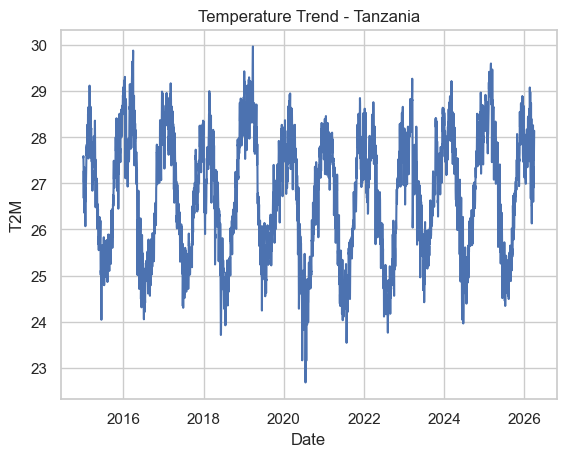

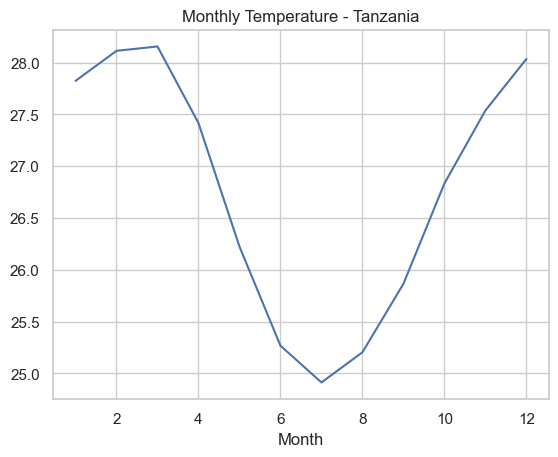

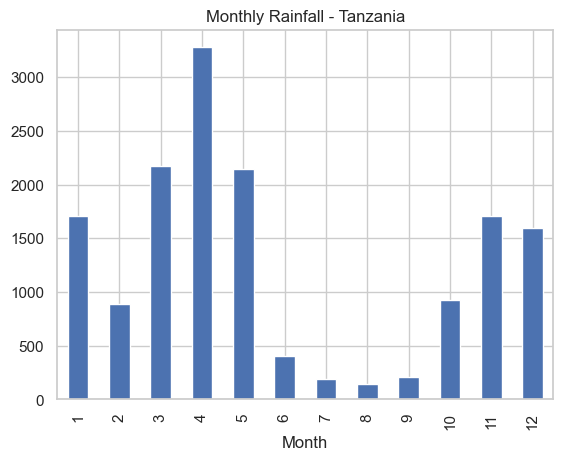

In [ ]:
# <Tanzania> Climate Analysis (2015–2026)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

sns.set(style="whitegrid")
df = pd.read_csv("../data/tanzania.csv")

# Add country column
df["Country"] = "Tanzania"

# Convert YEAR + DOY into datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Replace missing values (-999 is NASA sentinel value)
df.replace(-999, np.nan, inplace=True)

    # Remove duplicates
duplicates = df.duplicated().sum()
print("Tanzania duplicates:", duplicates)
df.drop_duplicates(inplace=True)

# Missing value percentage
missing_percent = df.isna().mean() * 100
print("Tanzania missing (%):\n", missing_percent)

# Handle missing values using forward-fill
# This is appropriate for time-series data to preserve continuity
df = df.ffill()

# Drop rows with excessive missing values (>30%)
df = df.dropna(thresh=int(0.7 * len(df.columns)))

# Outlier detection using Z-score
numeric_cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
outliers = (z_scores > 3)

print("Tanzania total outliers:", outliers.sum().sum())

# Note: Outliers are kept because they represent real extreme climate events


# ========================
# EDA
# ========================

# Temperature trend
sns.lineplot(data=df, x="Date", y="T2M")
plt.title("Temperature Trend - Tanzania")
plt.show()

# Monthly temperature
df.groupby("Month")["T2M"].mean().plot()
plt.title("Monthly Temperature - Tanzania")
plt.show()

# Rainfall
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall - Tanzania")
plt.show()

# Tanzania
## Tanzania shows relatively stable temperature and rainfall patterns.
